# Direct Fire Intensity Prediction v2
Per given feedback, we add a dedicated **regression-EDA** stage *before* model selection so the choice of model and target transformation is visually justified rather than just stated:
1. Plot the raw `frp` distribution and the `log(1+frp)` distribution side by side (skew quantified).
2. Plot scatterplots of FRP vs. key predictors (`fire_weather_index`, `temp_mean`, `wind_speed_max`) — both raw and log-transformed — to make the transformation argument visual.
3. Inspect the linearity of those relationships (and Pearson/Spearman correlations) to motivate the choice of a non-linear gradient-boosted model over plain linear regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from scipy import stats
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor

%matplotlib inline
sns.set_style('whitegrid')

## 1. Data Filtering & Preparation
We load the data, immediately drop any rows where `occured == 0`, and drop the `occured` column. The log transformation is **deferred** to after EDA so we can visualize the raw target as well.

In [3]:
df = pd.read_csv('wildfire.csv')

fire_only_df = df[df['occured'] == 1.0].copy()
fire_only_df = fire_only_df.drop(columns=['occured'])

print(f'Original dataset shape: {df.shape}')
print(f'Fire-only dataset shape: {fire_only_df.shape}')
fire_only_df.head()

Original dataset shape: (118858, 17)
Fire-only dataset shape: (59452, 16)


,daynight_N,lat,lon,fire_weather_index,pressure_mean,wind_direction_mean,wind_direction_std,solar_radiation_mean,dewpoint_mean,cloud_cover_mean,evapotranspiration_total,humidity_min,temp_mean,temp_range,wind_speed_max,frp
59406,0.0,12.13693,-14.72589,8.819078,1007.670833,177.750000,41.943663,258.958333,17.837500,57.833333,5.48,20.0,28.620833,18.5,13.3,8.85
59407,0.0,19.19217,103.63358,2.825200,846.708333,154.750000,118.604121,247.583333,11.891667,29.333333,4.13,38.0,17.512500,12.8,11.9,23.98
59408,0.0,59.64528,-115.91264,9.984760,954.491667,217.250000,21.366348,167.166667,4.233333,13.791667,4.21,30.0,16.337500,11.5,23.4,13.45
59409,0.0,-26.58425,29.23618,21.148859,843.220833,191.583333,155.428686,236.583333,-1.050000,10.583333,6.30,15.0,18.716667,15.3,28.0,17.90
59410,0.0,9.87594,32.50940,36.321522,965.058333,183.750000,164.672718,271.500000,6.154167,66.166667,9.46,13.0,32.762500,14.1,20.9,22.55


## 2. Regression EDA — Target Distribution
Before choosing a model, we inspect the target. FRP is known to be heavily right-skewed (a small number of mega-fires dominate). Quantifying skew tells us whether a log transform is warranted, and the side-by-side histogram makes that case visually.

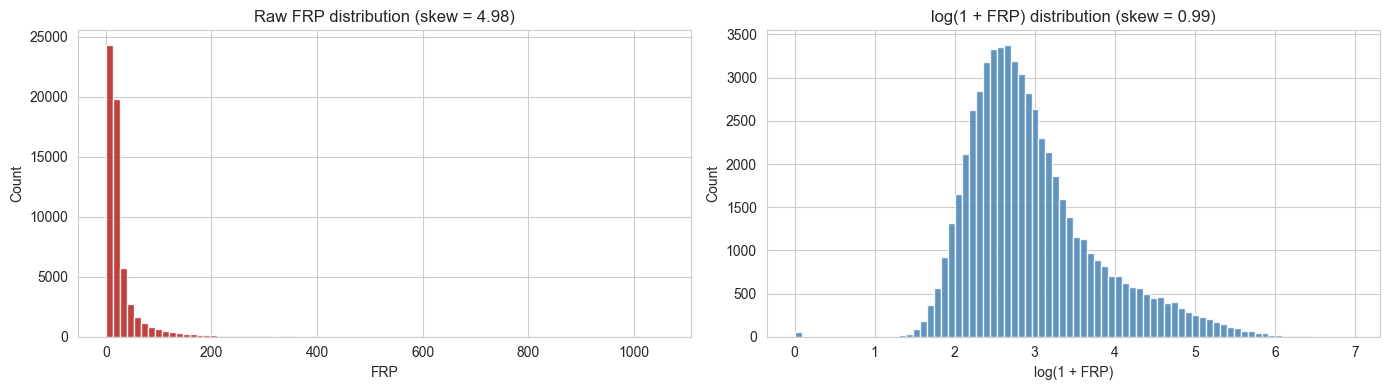

Raw FRP skew: 4.98  ->  log(1+FRP) skew: 0.99


In [4]:
frp_raw = fire_only_df['frp']
frp_log = np.log1p(frp_raw)

skew_raw = stats.skew(frp_raw)
skew_log = stats.skew(frp_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(frp_raw, bins=80, color='firebrick', alpha=0.85)
axes[0].set_title(f'Raw FRP distribution (skew = {skew_raw:.2f})')
axes[0].set_xlabel('FRP'); axes[0].set_ylabel('Count')

axes[1].hist(frp_log, bins=80, color='steelblue', alpha=0.85)
axes[1].set_title(f'log(1 + FRP) distribution (skew = {skew_log:.2f})')
axes[1].set_xlabel('log(1 + FRP)'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

print(f'Raw FRP skew: {skew_raw:.2f}  ->  log(1+FRP) skew: {skew_log:.2f}')

## 3. Regression EDA — Scatterplots of FRP vs Key Predictors
For each of three weather predictors that domain knowledge flags as drivers of fire intensity (`fire_weather_index`, `temp_mean`, `wind_speed_max`) we plot **raw FRP** and **log(1 + FRP)** side by side. The raw plots will look like noise punctuated by outlier spikes; the log plots reveal whatever monotonic structure actually exists.

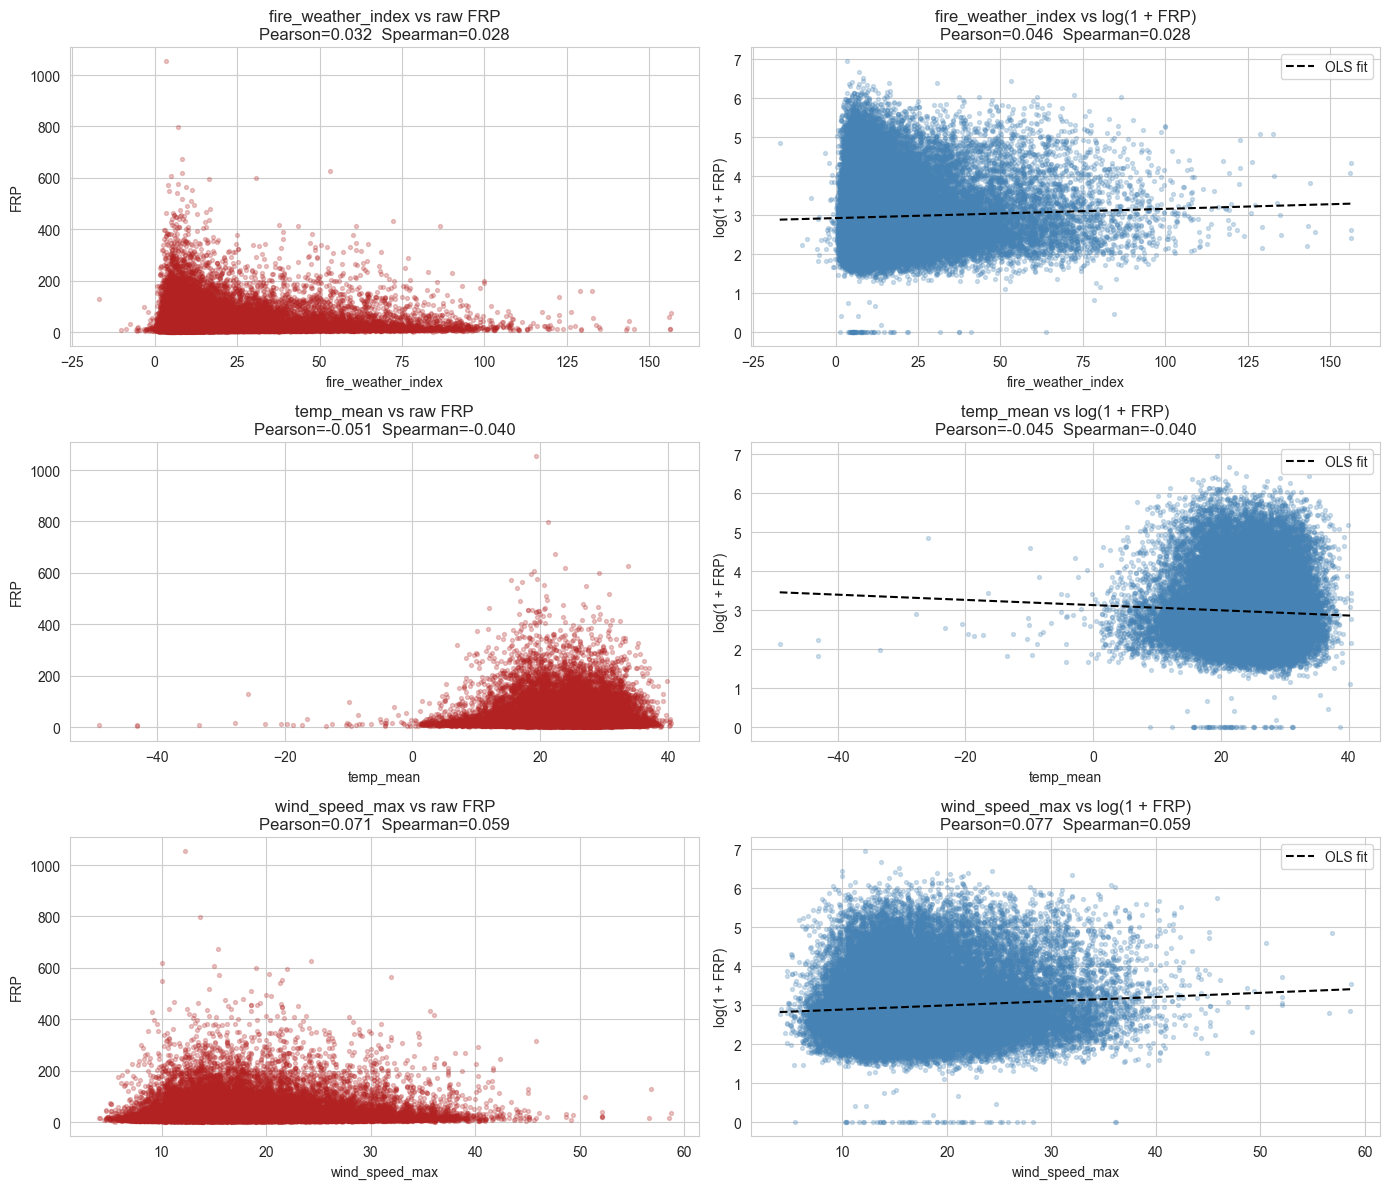

In [6]:
key_predictors = ['fire_weather_index', 'temp_mean', 'wind_speed_max']

fig, axes = plt.subplots(len(key_predictors), 2, figsize=(14, 4 * len(key_predictors)))

for i, feat in enumerate(key_predictors):
    x = fire_only_df[feat]

    # Raw FRP scatter
    axes[i, 0].scatter(x, frp_raw, alpha=0.25, s=8, color='firebrick')
    pearson_raw = np.corrcoef(x, frp_raw)[0, 1]
    spearman_raw = stats.spearmanr(x, frp_raw).correlation
    axes[i, 0].set_title(f'{feat} vs raw FRP\nPearson={pearson_raw:.3f}  Spearman={spearman_raw:.3f}')
    axes[i, 0].set_xlabel(feat); axes[i, 0].set_ylabel('FRP')

    # Log FRP scatter with linear-regression reference line
    axes[i, 1].scatter(x, frp_log, alpha=0.25, s=8, color='steelblue')
    pearson_log = np.corrcoef(x, frp_log)[0, 1]
    spearman_log = stats.spearmanr(x, frp_log).correlation
    lr = LinearRegression().fit(x.values.reshape(-1, 1), frp_log.values)
    xs = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    axes[i, 1].plot(xs, lr.predict(xs), color='black', linestyle='--', linewidth=1.5, label='OLS fit')
    axes[i, 1].set_title(f'{feat} vs log(1 + FRP)\nPearson={pearson_log:.3f}  Spearman={spearman_log:.3f}')
    axes[i, 1].set_xlabel(feat); axes[i, 1].set_ylabel('log(1 + FRP)')
    axes[i, 1].legend(loc='best')

plt.tight_layout(); plt.show()

* **Raw scatters** are dominated by a few extreme FRP spikes — visually they look like noise. A linear model fit to this would chase the outliers.
* **Log scatters** make the (weak) monotonic trends visible and stabilize the variance, which is the visual justification for modeling `log(1 + FRP)`.
* The relationships are **monotonic but clearly non-linear and noisy** (low Pearson, modestly higher Spearman). A linear regression will under-fit; a flexible non-linear model that handles interactions natively (gradient-boosted trees) is the better fit.

## 4. Regression EDA — Pairwise Correlations
A Pearson/Spearman heatmap of all predictors against `log(1 + FRP)` confirms that no single weather variable is strongly linearly predictive — another argument for a non-linear ensemble model.

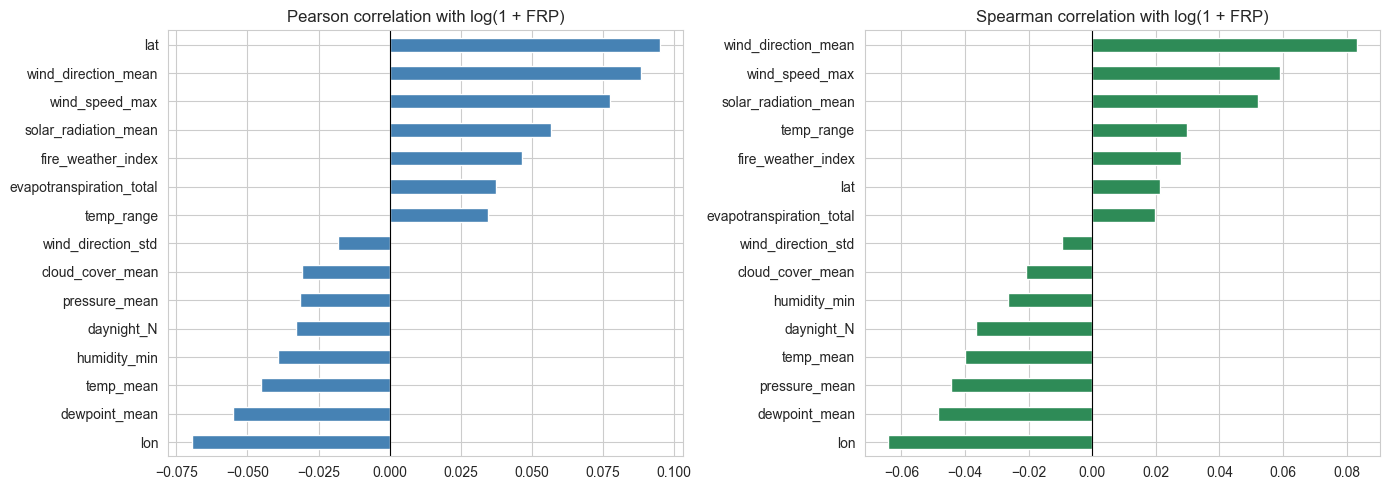

In [7]:
eda_df = fire_only_df.copy()
eda_df['log_frp'] = frp_log

pearson_corr = eda_df.corr(method='pearson')['log_frp'].drop(['frp', 'log_frp']).sort_values()
spearman_corr = eda_df.corr(method='spearman')['log_frp'].drop(['frp', 'log_frp']).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pearson_corr.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Pearson correlation with log(1 + FRP)')
axes[0].axvline(0, color='black', linewidth=0.8)

spearman_corr.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Spearman correlation with log(1 + FRP)')
axes[1].axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()

## 5. Model Selection Rationale

In [8]:
X = fire_only_df.drop(columns=['frp'])
y = np.log1p(fire_only_df['frp'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

Training set shape: (47561, 15)
Testing set shape: (11891, 15)


## 6. Baseline — Linear Regression
Quick check that a linear model is in fact insufficient, as the scatterplots suggested.

In [9]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_log_preds = lin_model.predict(X_test)

lin_r2_log = r2_score(y_test, lin_log_preds)
lin_mae_real = mean_absolute_error(np.expm1(y_test), np.expm1(lin_log_preds))
print(f'Linear baseline  -  R2 (log space): {lin_r2_log:.4f}   MAE (real FRP): {lin_mae_real:.2f}')

Linear baseline  -  R2 (log space): 0.0397   MAE (real FRP): 17.68


## 7. Main Model — LightGBM

In [10]:
reg_model = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=50,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

reg_model.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


## 8. Evaluation & Insights
We evaluate strictly on the testing subset of the **fire-only** data, reversing the `log1p` transformation to report real-world errors.

LightGBM  -  R2 (log space): 0.1178   R2 (real FRP): 0.0466   MAE (real FRP): 17.24
Lift over linear baseline (log-space R2): +0.0781


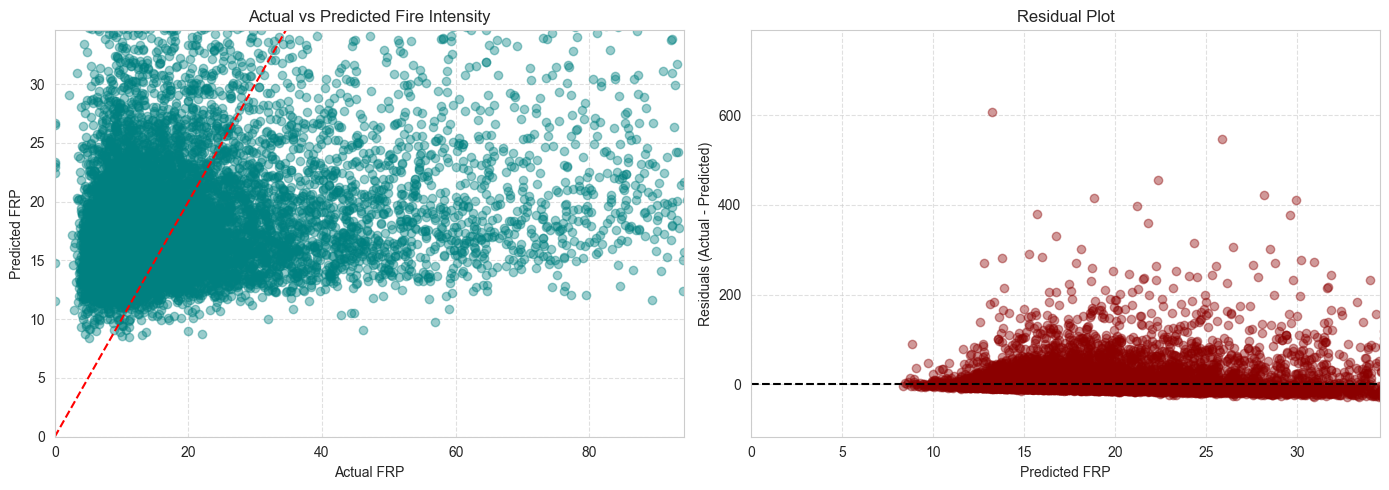

In [11]:
log_preds = reg_model.predict(X_test)

y_test_real = np.expm1(y_test)
preds_real = np.expm1(log_preds)

r2_log = r2_score(y_test, log_preds)
r2 = r2_score(y_test_real, preds_real)
mae = mean_absolute_error(y_test_real, preds_real)

print(f'LightGBM  -  R2 (log space): {r2_log:.4f}   R2 (real FRP): {r2:.4f}   MAE (real FRP): {mae:.2f}')
print(f'Lift over linear baseline (log-space R2): +{(r2_log - lin_r2_log):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_real, preds_real, alpha=0.4, color='teal')
axes[0].plot([0, max(y_test_real)], [0, max(y_test_real)], 'r--')
axes[0].set_xlabel('Actual FRP'); axes[0].set_ylabel('Predicted FRP')
axes[0].set_title('Actual vs Predicted Fire Intensity')
axes[0].set_xlim(0, np.percentile(y_test_real, 95))
axes[0].set_ylim(0, np.percentile(preds_real, 95))
axes[0].grid(True, linestyle='--', alpha=0.6)

residuals = y_test_real - preds_real
axes[1].scatter(preds_real, residuals, alpha=0.4, color='darkred')
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel('Predicted FRP'); axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].set_xlim(0, np.percentile(preds_real, 95))
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(); plt.show()

## 9. Feature Importance
What factors drive the intensity of a fire once it has already started?

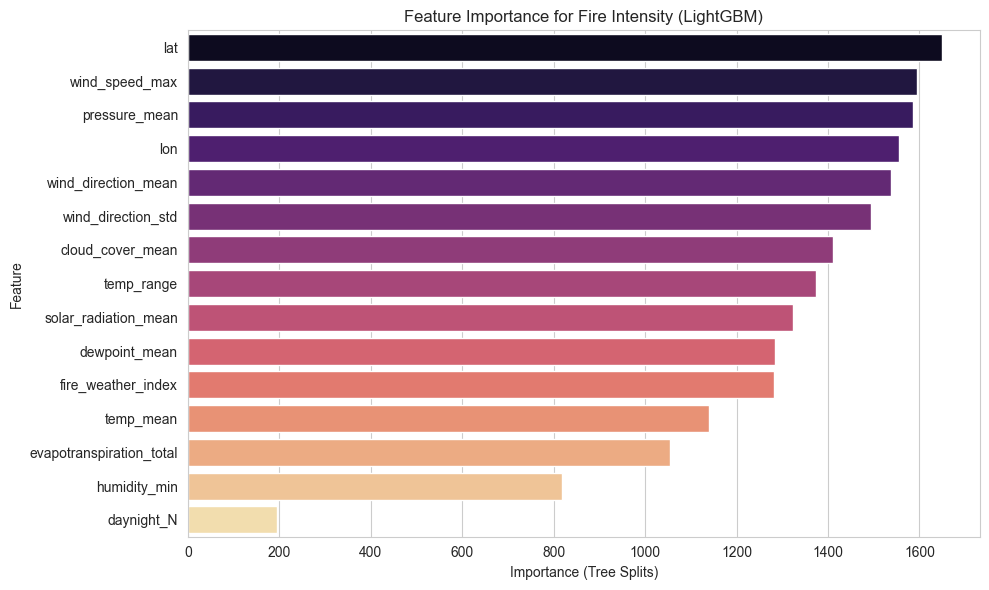

In [12]:
importance = reg_model.feature_importances_
features = X_train.columns

fi_df = pd.DataFrame({'Feature': features, 'Importance': importance})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')
plt.title('Feature Importance for Fire Intensity (LightGBM)')
plt.xlabel('Importance (Tree Splits)'); plt.ylabel('Feature')
plt.tight_layout(); plt.show()

## 10. Save Model

In [13]:
joblib.dump(reg_model, 'direct_fire_intensity_lgbm_v2.pkl')
print("Model saved successfully as 'direct_fire_intensity_lgbm_v2.pkl'")

Model saved successfully as 'direct_fire_intensity_lgbm_v2.pkl'
